In [1]:
import numpy as np
import pandas as pd

from scipy.stats import shapiro, levene, ttest_ind, mannwhitneyu
from statsmodels.stats.multitest import multipletests

import seaborn as sns

# 3D and 3E, INS1 and INS2 mRNA levels

In [2]:
df= pd.read_excel('41467_2025_65060_MOESM11_ESM.xlsx', sheet_name='Fig 3D (log Ins1 mRNA)', skiprows=1)

# ------------------------------------------------------------
# Columns
# ------------------------------------------------------------
reference = "NC"

comparison_cols = [
    "Tmem176a/b",
    "Dbi",
    "Cebpg",
    "Dstn",
    "Gabarap",
    "Spire1",
    "Atraid"
]


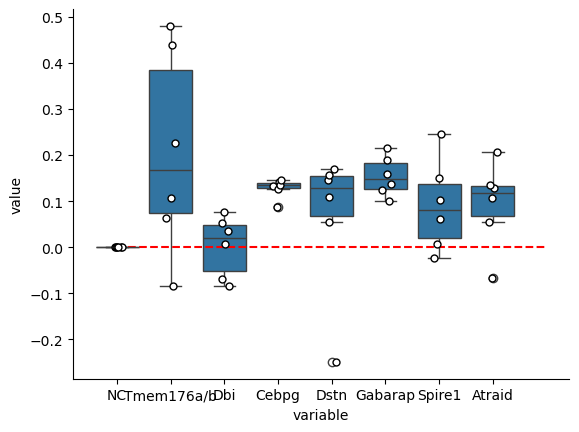

In [3]:
sns.boxplot(df.melt(), x='variable', y='value')
sns.stripplot(df.melt(), x='variable', y='value', c='w', linewidth=1, edgecolor='k')
sns.lineplot(x=[0,8], y=[0,0], c='r', linestyle='--')

sns.despine()

In [4]:
results = []

for col in comparison_cols:

    nc = df[reference].dropna()
    other = df[col].dropna()

    # Normality
    nc_shapiro = shapiro(nc)
    other_shapiro = shapiro(other)

    # Equal variance
    lev = levene(nc, other, center="median")

    # Welch
    welch = ttest_ind(
        nc,
        other,
        equal_var=False
    )

    # Mann-Whitney U
    mw = mannwhitneyu(
        nc,
        other,
        alternative="two-sided"
    )

    results.append({
        "Gene": col,
        "NC_n": len(nc),
        "Other_n": len(other),

        "NC_Shapiro_p": nc_shapiro.pvalue,
        "Other_Shapiro_p": other_shapiro.pvalue,

        "Levene_p": lev.pvalue,

        "Welch_t": welch.statistic,
        "Welch_p": welch.pvalue,

        "MW_U": mw.statistic,
        "MW_p": mw.pvalue,
    })


results_df = pd.DataFrame(results)

# BY correction, separately for each family of tests
results_df["Welch_p_BY"] = multipletests(
    results_df["Welch_p"],
    method="fdr_by"
)[1]

results_df["MW_p_BY"] = multipletests(
    results_df["MW_p"],
    method="fdr_by"
)[1]

# Significance
results_df["Welch_sig"] = results_df["Welch_p_BY"] < 0.05
results_df["MW_sig"] = results_df["MW_p_BY"] < 0.05

# Nice rounding
p_cols = [
    "NC_Shapiro_p",
    "Other_Shapiro_p",
    "Levene_p",
    "Welch_p",
    "Welch_p_BY",
    "MW_p",
    "MW_p_BY"
]

results_df[p_cols] = results_df[p_cols].round(6)

results_df

C:\Users\Leo\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


,Gene,NC_n,Other_n,NC_Shapiro_p,Other_Shapiro_p,Levene_p,Welch_t,Welch_p,MW_U,MW_p,Welch_p_BY,MW_p_BY,Welch_sig,MW_sig
0,Tmem176a/b,6,6,1.0,0.658617,0.003769,-2.270171,0.072423,6.0,0.049336,0.269177,0.149242,False,False
1,Dbi,6,6,1.0,0.403087,0.007964,-0.097214,0.926333,12.0,0.347164,1.000000,0.900145,False,False
2,Cebpg,6,6,1.0,0.040026,0.108456,-14.696010,0.000026,0.0,0.002778,0.000478,0.025214,True,True
3,Dstn,6,6,1.0,0.009481,0.135999,-0.995082,0.365384,6.0,0.049336,1.000000,0.149242,False,False
4,Gabarap,6,6,1.0,0.925645,0.004070,-8.827172,0.000310,0.0,0.002778,0.002813,0.025214,True,True
5,Spire1,6,6,1.0,0.867953,0.006955,-2.251326,0.074154,6.0,0.049336,0.269177,0.149242,False,False
6,Atraid,6,6,1.0,0.577531,0.047435,-2.477078,0.056042,6.0,0.049336,0.269177,0.149242,False,False


In [5]:
results_df.to_excel('Suple/Table2_1.xlsx')

In [6]:
df= pd.read_excel('41467_2025_65060_MOESM11_ESM.xlsx', sheet_name='Figure 3E (log Ins2 mRNA)', skiprows=1)

# ------------------------------------------------------------
# Columns
# ------------------------------------------------------------
reference = "NC"

comparison_cols = [
    "Tmem176a/b",
    "Dbi",
    "Cebpg",
    "Dstn",
    "Gabarap",
    "Spire1",
    "Atraid"
]


In [7]:
results = []

for col in comparison_cols:

    nc = df[reference].dropna()
    other = df[col].dropna()

    # Normality
    nc_shapiro = shapiro(nc)
    other_shapiro = shapiro(other)

    # Equal variance
    lev = levene(nc, other, center="median")

    # Welch
    welch = ttest_ind(
        nc,
        other,
        equal_var=False
    )

    # Mann-Whitney U
    mw = mannwhitneyu(
        nc,
        other,
        alternative="two-sided"
    )

    results.append({
        "Gene": col,
        "NC_n": len(nc),
        "Other_n": len(other),

        "NC_Shapiro_p": nc_shapiro.pvalue,
        "Other_Shapiro_p": other_shapiro.pvalue,

        "Levene_p": lev.pvalue,

        "Welch_t": welch.statistic,
        "Welch_p": welch.pvalue,

        "MW_U": mw.statistic,
        "MW_p": mw.pvalue,
    })


results_df = pd.DataFrame(results)

# BY correction, separately for each family of tests
results_df["Welch_p_BY"] = multipletests(
    results_df["Welch_p"],
    method="fdr_by"
)[1]

results_df["MW_p_BY"] = multipletests(
    results_df["MW_p"],
    method="fdr_by"
)[1]

# Significance
results_df["Welch_sig"] = results_df["Welch_p_BY"] < 0.05
results_df["MW_sig"] = results_df["MW_p_BY"] < 0.05

# Nice rounding
p_cols = [
    "NC_Shapiro_p",
    "Other_Shapiro_p",
    "Levene_p",
    "Welch_p",
    "Welch_p_BY",
    "MW_p",
    "MW_p_BY"
]

results_df[p_cols] = results_df[p_cols].round(6)

results_df

C:\Users\Leo\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: Input data has range zero. The results may not be accurate.
  res = hypotest_fun_out(*samples, **kwds)


,Gene,NC_n,Other_n,NC_Shapiro_p,Other_Shapiro_p,Levene_p,Welch_t,Welch_p,MW_U,MW_p,Welch_p_BY,MW_p_BY,Welch_sig,MW_sig
0,Tmem176a/b,6,6,1.0,0.269847,0.042511,-0.202511,0.847500,12.0,0.347164,1.000000,1.000000,False,False
1,Dbi,6,6,1.0,0.069839,0.100194,-0.966784,0.378054,12.0,0.347164,1.000000,1.000000,False,False
2,Cebpg,6,6,1.0,0.031017,0.048067,-5.680739,0.002355,0.0,0.002619,0.021368,0.035306,True,True
3,Dstn,6,6,1.0,0.017069,0.149318,-0.251694,0.811295,6.0,0.049336,1.000000,0.223863,False,False
4,Gabarap,6,5,1.0,0.615503,0.011812,-14.702206,0.000125,0.0,0.003890,0.002261,0.035306,True,True
5,Spire1,6,6,1.0,0.305435,0.000533,-0.987553,0.368720,18.0,1.000000,1.000000,1.000000,False,False
6,Atraid,6,6,1.0,0.604298,0.054505,-3.574773,0.015963,6.0,0.049336,0.096575,0.223863,False,False


In [8]:
results_df.to_excel('Suple/Table2_2.xlsx')

# 3F Insulin Response

In [9]:
def compare_gene_to_nc(df, reference="NC"):
    """
    Compare the gene group against NC for every condition.

    Expected dataframe structure:
    
                         Condition1  Condition2  Condition3
    NC                       ...         ...         ...
    NC                       ...         ...         ...
    NC                       ...         ...         ...
    Gene                     ...         ...         ...
    Gene                     ...         ...         ...
    Gene                     ...         ...         ...

    The index contains group names and can contain multiple
    replicate rows for each group.

    Returns
    -------
    pandas.DataFrame
        Statistical test results for each condition.
    """

    results = []

    # ---------------------------------------------------------
    # Identify groups
    # ---------------------------------------------------------

    groups = df.index.unique().tolist()

    if reference not in groups:
        raise ValueError(
            f"Reference group '{reference}' was not found in dataframe index."
        )

    other_groups = [x for x in groups if x != reference]

    if len(other_groups) != 1:
        raise ValueError(
            f"Expected exactly one group besides '{reference}', "
            f"but found: {other_groups}"
        )

    gene = other_groups[0]

    # ---------------------------------------------------------
    # Helper functions
    # ---------------------------------------------------------

    def get_numeric_values(group, condition):

        values = df.loc[group, condition]

        # df.loc can return a scalar if there is only one row
        if np.isscalar(values):
            values = pd.Series([values])
        else:
            values = pd.Series(values)

        # Convert strings/object values to numeric
        values = pd.to_numeric(
            values,
            errors="coerce"
        )

        return values.dropna().astype(float)

    def shapiro_safe(values):

        if len(values) < 3:
            return np.nan

        # Constant data have zero range
        if np.ptp(values) == 0:
            return np.nan

        return shapiro(values).pvalue

    def levene_safe(x, y):

        if len(x) < 2 or len(y) < 2:
            return np.nan

        var_x = np.var(x, ddof=1)
        var_y = np.var(y, ddof=1)

        # Both groups have zero variance
        if var_x == 0 and var_y == 0:
            return np.nan

        return levene(
            x,
            y,
            center="median"
        ).pvalue

    def ttest_safe(x, y, equal_var):

        if len(x) < 2 or len(y) < 2:
            return np.nan, np.nan

        var_x = np.var(x, ddof=1)
        var_y = np.var(y, ddof=1)

        # Both groups have zero variance
        if var_x == 0 and var_y == 0:

            # Same constant value
            if np.mean(x) == np.mean(y):
                return np.nan, np.nan

            # Different constant values
            return np.inf, 0.0

        test = ttest_ind(
            x,
            y,
            equal_var=equal_var
        )

        return test.statistic, test.pvalue

    def mannwhitney_safe(x, y):

        if len(x) == 0 or len(y) == 0:
            return np.nan, np.nan

        # Both groups identical constants
        if (
            np.ptp(x) == 0
            and np.ptp(y) == 0
            and np.mean(x) == np.mean(y)
        ):
            return np.nan, np.nan

        test = mannwhitneyu(
            x,
            y,
            alternative="two-sided"
        )

        return test.statistic, test.pvalue

    # ---------------------------------------------------------
    # Run tests for every condition
    # ---------------------------------------------------------

    for condition in df.columns:

        nc = get_numeric_values(
            reference,
            condition
        )

        gene_values = get_numeric_values(
            gene,
            condition
        )

        # -----------------------------------------------------
        # Normality
        # -----------------------------------------------------

        nc_shapiro_p = shapiro_safe(nc)
        gene_shapiro_p = shapiro_safe(gene_values)

        # -----------------------------------------------------
        # Equal variances
        # -----------------------------------------------------

        levene_p = levene_safe(
            nc,
            gene_values
        )

        # -----------------------------------------------------
        # Student's t-test
        # -----------------------------------------------------

        student_t, student_p = ttest_safe(
            nc,
            gene_values,
            equal_var=True
        )

        # -----------------------------------------------------
        # Welch's t-test
        # -----------------------------------------------------

        welch_t, welch_p = ttest_safe(
            nc,
            gene_values,
            equal_var=False
        )

        # -----------------------------------------------------
        # Mann-Whitney U
        # -----------------------------------------------------

        mw_u, mw_p = mannwhitney_safe(
            nc,
            gene_values
        )

        # -----------------------------------------------------
        # Store results
        # -----------------------------------------------------

        results.append({
            "Gene": gene,
            "Condition": condition,

            "NC_n": len(nc),
            "Gene_n": len(gene_values),

            "NC_Shapiro_p": nc_shapiro_p,
            "Gene_Shapiro_p": gene_shapiro_p,

            "Levene_p": levene_p,

            "Student_t": student_t,
            "Student_p": student_p,

            "Welch_t": welch_t,
            "Welch_p": welch_p,

            "MW_U": mw_u,
            "MW_p": mw_p
        })

    # ---------------------------------------------------------
    # Results dataframe
    # ---------------------------------------------------------

    results_df = pd.DataFrame(results)

    # ---------------------------------------------------------
    # Round p-values
    # ---------------------------------------------------------

    p_cols = [
        "NC_Shapiro_p",
        "Gene_Shapiro_p",
        "Levene_p",
        "Student_p",
        "Welch_p",
        "MW_p"
    ]

    results_df[p_cols] = results_df[p_cols].round(6)

    return results_df

In [10]:
df= pd.read_excel('41467_2025_65060_MOESM11_ESM.xlsx', sheet_name='Figure 3F (GSIS)', index_col=0)#, skiprows=1)




In [11]:
tmem=df.iloc[1:4,0:10].copy()
tmem.columns=['NC']*5+['Tmem176a/b DKD']*5
tmem=tmem.T
tmem=tmem.astype(float)

In [12]:
compare_gene_to_nc(tmem)

C:\Users\Leo\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,Gene,Condition,NC_n,Gene_n,NC_Shapiro_p,Gene_Shapiro_p,Levene_p,Student_t,Student_p,Welch_t,Welch_p,MW_U,MW_p
0,Tmem176a/b DKD,2.8 mM Glucose,5,5,NaN,0.368769,0.108021,0.580635,0.577472,0.580635,0.592628,20.0,0.118797
1,Tmem176a/b DKD,16.7 mM Glucose,5,5,0.246486,0.221565,0.196178,-0.207106,0.841102,-0.207106,0.843646,13.0,1.000000
2,Tmem176a/b DKD,16.7 mM Glucose + IBMX,5,5,0.471869,0.690139,0.019251,-2.133413,0.065444,-2.133413,0.096428,6.0,0.207300


In [13]:
dbi=df.iloc[7:10,0:12].copy()
dbi.columns=['NC']*6+['Dbi KD']*6
dbi=dbi.T
dbi=dbi.astype(float)

In [14]:
compare_gene_to_nc(dbi)

C:\Users\Leo\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


,Gene,Condition,NC_n,Gene_n,NC_Shapiro_p,Gene_Shapiro_p,Levene_p,Student_t,Student_p,Welch_t,Welch_p,MW_U,MW_p
0,Dbi KD,2.8 mM Glucose,6,6,NaN,0.361881,0.022046,3.665541,0.004349,3.665541,0.014511,36.0,0.002778
1,Dbi KD,16.7 mM Glucose,6,6,0.001443,0.037786,0.557889,0.400091,0.697502,0.400091,0.700837,17.0,0.937229
2,Dbi KD,16.7 mM Glucose + IBMX,6,6,0.008836,0.635326,0.744054,-1.033829,0.325570,-1.033829,0.325701,10.0,0.240260


In [15]:
cebpg=df.iloc[13:16,0:14].copy()
cebpg.columns=['NC']*7+['Cebpg KD']*7
cebpg=cebpg.T
cebpg=cebpg.astype(float)

In [16]:
compare_gene_to_nc(cebpg)

,Gene,Condition,NC_n,Gene_n,NC_Shapiro_p,Gene_Shapiro_p,Levene_p,Student_t,Student_p,Welch_t,Welch_p,MW_U,MW_p
0,Cebpg KD,2.8 mM Glucose,7,7,0.000275,0.036139,0.048877,-5.658859,0.000106,-5.658859,0.001308,0.0,0.001690
1,Cebpg KD,16.7 mM Glucose,7,7,0.354962,0.174686,0.137909,-3.073967,0.009645,-3.073967,0.016699,3.0,0.004079
2,Cebpg KD,16.7 mM Glucose + IBMX,7,7,0.224031,0.651778,0.395352,-1.784670,0.099596,-1.784670,0.106199,12.0,0.128205


In [17]:
dstn=df.iloc[19:22,0:12].copy()
dstn.columns=['NC']*6+['Dstn KD']*6
dstn=dstn.T
dstn=dstn.astype(float)

In [18]:
compare_gene_to_nc(dstn)

,Gene,Condition,NC_n,Gene_n,NC_Shapiro_p,Gene_Shapiro_p,Levene_p,Student_t,Student_p,Welch_t,Welch_p,MW_U,MW_p
0,Dstn KD,2.8 mM Glucose,6,6,0.527164,0.835869,0.547510,0.997558,0.342019,0.997558,0.345682,27.0,0.179654
1,Dstn KD,16.7 mM Glucose,6,6,0.388259,0.859392,0.494879,-0.099523,0.922690,-0.099523,0.923340,16.0,0.818182
2,Dstn KD,16.7 mM Glucose + IBMX,6,6,0.603763,0.569092,0.343996,1.280562,0.229251,1.280562,0.233894,24.0,0.393939


In [19]:
gabarap=df.iloc[25:28,0:12].copy()
gabarap.columns=['NC']*6+['Gabarap KD']*6
gabarap=gabarap.T
gabarap=gabarap.astype(float)

In [20]:
compare_gene_to_nc(gabarap)

,Gene,Condition,NC_n,Gene_n,NC_Shapiro_p,Gene_Shapiro_p,Levene_p,Student_t,Student_p,Welch_t,Welch_p,MW_U,MW_p
0,Gabarap KD,2.8 mM Glucose,6,6,0.911045,0.406867,0.082503,-1.256563,0.237471,-1.256563,0.245529,12.0,0.393939
1,Gabarap KD,16.7 mM Glucose,6,6,0.959296,0.247873,0.054084,-4.574007,0.001020,-4.574007,0.005241,0.0,0.002165
2,Gabarap KD,16.7 mM Glucose + IBMX,6,6,0.157848,0.579579,0.024195,-3.503550,0.005693,-3.503550,0.015300,1.0,0.004329


In [21]:
spire=df.iloc[31:34,0:12].copy()
spire.columns=['NC']*6+['Spire1 KD']*6
spire=spire.T
spire=spire.astype(float)

In [22]:
compare_gene_to_nc(spire)

,Gene,Condition,NC_n,Gene_n,NC_Shapiro_p,Gene_Shapiro_p,Levene_p,Student_t,Student_p,Welch_t,Welch_p,MW_U,MW_p
0,Spire1 KD,2.8 mM Glucose,6,6,0.044412,0.059908,0.935296,-0.057389,0.955366,-0.057389,0.955367,16.0,0.818182
1,Spire1 KD,16.7 mM Glucose,5,6,0.534080,0.688244,0.011308,-2.234898,0.052277,-2.468132,0.056036,5.0,0.082251
2,Spire1 KD,16.7 mM Glucose + IBMX,6,6,0.295102,0.550209,0.274042,-1.837549,0.095983,-1.837549,0.103388,8.0,0.132035


In [23]:
atraid=df.iloc[37:40,0:14].copy()
atraid=atraid.replace('3,09267967*',3.09267967)
atraid.columns=['NC']*7+['Atraid KD']*7
atraid=atraid.T
atraid=atraid.astype(float)

C:\Users\Leo\AppData\Local\Temp\ipykernel_15216\926390063.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  atraid=atraid.replace('3,09267967*',3.09267967)


In [24]:
compare_gene_to_nc(atraid)

,Gene,Condition,NC_n,Gene_n,NC_Shapiro_p,Gene_Shapiro_p,Levene_p,Student_t,Student_p,Welch_t,Welch_p,MW_U,MW_p
0,Atraid KD,2.8 mM Glucose,7,7,0.110989,0.041736,0.206818,-2.082948,0.059312,-2.082948,0.073299,11.0,0.097319
1,Atraid KD,16.7 mM Glucose,7,7,0.012413,0.285110,0.319309,-2.852424,0.014557,-2.852424,0.017715,6.0,0.017483
2,Atraid KD,16.7 mM Glucose + IBMX,7,7,0.773140,0.625739,0.012205,-4.628253,0.000582,-4.628253,0.003225,0.0,0.000583


In [25]:
all_=pd.concat([compare_gene_to_nc(tmem), 
                compare_gene_to_nc(dbi), 
                compare_gene_to_nc(cebpg), 
                compare_gene_to_nc(dstn), 
                compare_gene_to_nc(gabarap), 
                compare_gene_to_nc(spire), 
                compare_gene_to_nc(atraid)])

C:\Users\Leo\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)
C:\Users\Leo\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:586: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  res = hypotest_fun_out(*samples, **kwds)


In [26]:
all_[all_.Student_p<0.05]

,Gene,Condition,NC_n,Gene_n,NC_Shapiro_p,Gene_Shapiro_p,Levene_p,Student_t,Student_p,Welch_t,Welch_p,MW_U,MW_p
0,Dbi KD,2.8 mM Glucose,6,6,NaN,0.361881,0.022046,3.665541,0.004349,3.665541,0.014511,36.0,0.002778
0,Cebpg KD,2.8 mM Glucose,7,7,0.000275,0.036139,0.048877,-5.658859,0.000106,-5.658859,0.001308,0.0,0.001690
1,Cebpg KD,16.7 mM Glucose,7,7,0.354962,0.174686,0.137909,-3.073967,0.009645,-3.073967,0.016699,3.0,0.004079
1,Gabarap KD,16.7 mM Glucose,6,6,0.959296,0.247873,0.054084,-4.574007,0.001020,-4.574007,0.005241,0.0,0.002165
2,Gabarap KD,16.7 mM Glucose + IBMX,6,6,0.157848,0.579579,0.024195,-3.503550,0.005693,-3.503550,0.015300,1.0,0.004329
1,Atraid KD,16.7 mM Glucose,7,7,0.012413,0.285110,0.319309,-2.852424,0.014557,-2.852424,0.017715,6.0,0.017483
2,Atraid KD,16.7 mM Glucose + IBMX,7,7,0.773140,0.625739,0.012205,-4.628253,0.000582,-4.628253,0.003225,0.0,0.000583


In [27]:
all_.to_excel('Suple/Table3.xlsx')

## Plots

<Axes: xlabel='Figure 3F', ylabel='value'>

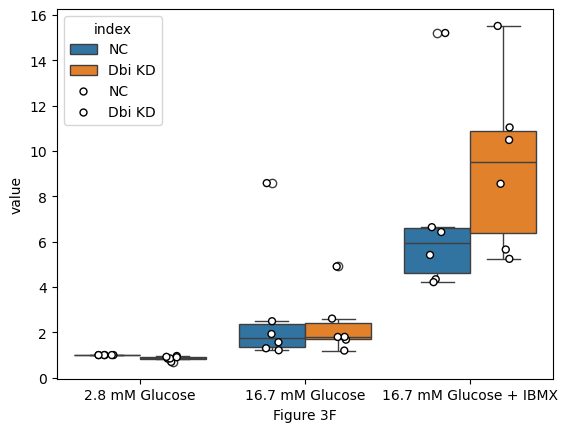

In [28]:
sns.boxplot(dbi.melt(ignore_index=False).reset_index(), x='Figure 3F', y='value', hue='index', dodge=True)
sns.stripplot(dbi.melt(ignore_index=False).reset_index(), x='Figure 3F', y='value', hue='index', dodge=True, linewidth=1, palette=['white'] * spire.index.nunique(),edgecolor='black')

<Axes: xlabel='Figure 3F', ylabel='value'>

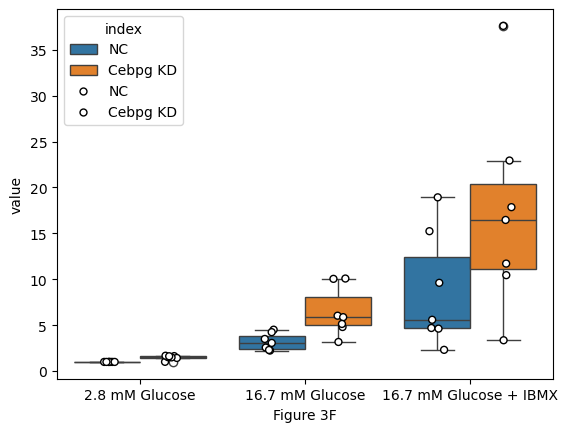

In [29]:
sns.boxplot(cebpg.melt(ignore_index=False).reset_index(), x='Figure 3F', y='value', hue='index', dodge=True)
sns.stripplot(cebpg.melt(ignore_index=False).reset_index(), x='Figure 3F', y='value', hue='index', dodge=True, linewidth=1, palette=['white'] * spire.index.nunique(),edgecolor='black')

<Axes: xlabel='Figure 3F', ylabel='value'>

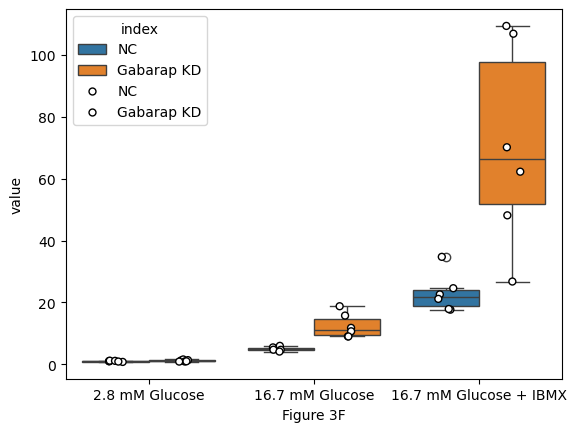

In [30]:
sns.boxplot(gabarap.melt(ignore_index=False).reset_index(), x='Figure 3F', y='value', hue='index', dodge=True)
sns.stripplot(gabarap.melt(ignore_index=False).reset_index(), x='Figure 3F', y='value', hue='index', dodge=True, linewidth=1, palette=['white'] * spire.index.nunique(),edgecolor='black')

<Axes: xlabel='Figure 3F', ylabel='value'>

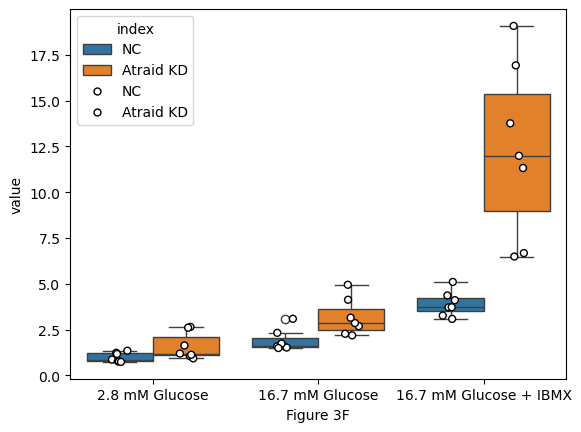

In [31]:
sns.boxplot(atraid.melt(ignore_index=False).reset_index(), x='Figure 3F', y='value', hue='index', dodge=True)
sns.stripplot(atraid.melt(ignore_index=False).reset_index(), x='Figure 3F', y='value', hue='index', dodge=True, linewidth=1, palette=['white'] * spire.index.nunique(),edgecolor='black')

### Merging NC values across experiments would change things further...

In [32]:
merge=pd.concat([tmem, dbi, dstn, spire, gabarap, cebpg, atraid]).loc[['NC','Cebpg KD'],:]

<Axes: xlabel='Figure 3F', ylabel='value'>

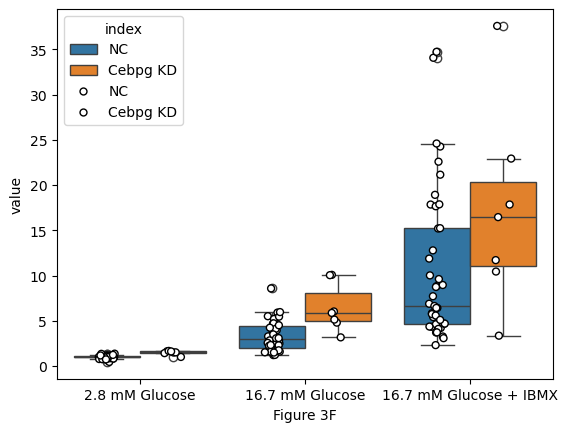

In [33]:
sns.boxplot(merge.melt(ignore_index=False).reset_index(), x='Figure 3F', y='value', hue='index', dodge=True)
sns.stripplot(merge.melt(ignore_index=False).reset_index(), x='Figure 3F', y='value', hue='index', dodge=True, linewidth=1, palette=['white'] * spire.index.nunique(),edgecolor='black')

# 5B

In [34]:
df= pd.read_excel('41467_2025_65060_MOESM11_ESM.xlsx', sheet_name='Fig6B (beta cells mass TmemDKO)', skiprows=1)


In [35]:
df = df.replace('0,093245047*', 0.093245047)
df = df.replace('0,013155284*', 0.013155284)

C:\Users\Leo\AppData\Local\Temp\ipykernel_15216\228480583.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('0,093245047*', 0.093245047)
C:\Users\Leo\AppData\Local\Temp\ipykernel_15216\228480583.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace('0,013155284*', 0.013155284)


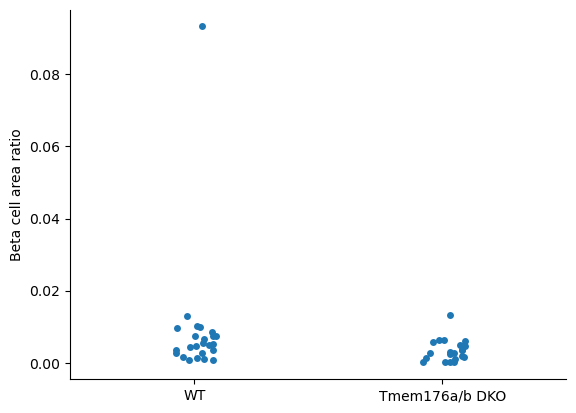

In [36]:
import matplotlib.pyplot as plt
sns.stripplot(df.melt().dropna(), x='variable', y='value')
sns.despine()

plt.xlabel('')
plt.ylabel('Beta cell area ratio')

plt.savefig('Suple/S1_A_Figure5B_data.svg')

In [37]:
df=df[df<0.08].copy()

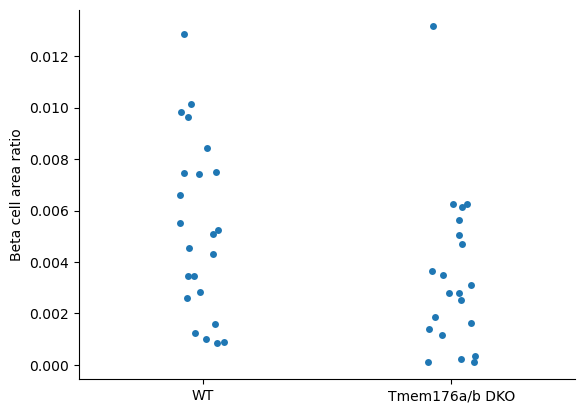

In [38]:
import matplotlib.pyplot as plt
sns.stripplot(df.melt().dropna(), x='variable', y='value')
sns.despine()

plt.xlabel('')
plt.ylabel('Beta cell area ratio')


plt.savefig('Suple/S1_B_Figure5B_data.svg')

In [39]:
# ------------------------------------------------------------
# Columns
# ------------------------------------------------------------
reference = "WT"

comparison_cols = [
    "Tmem176a/b DKO"
]

In [40]:
results = []

for col in comparison_cols:

    nc = df[reference].dropna()
    other = df[col].dropna()

    # -------------------------
    # Normality
    # -------------------------
    nc_shapiro = shapiro(nc)
    other_shapiro = shapiro(other)

    # -------------------------
    # Equal variance
    # -------------------------
    lev = levene(
        nc,
        other,
        center="median"
    )

    # -------------------------
    # Student's t-test
    # Assumes equal variances
    # -------------------------
    student = ttest_ind(
        nc,
        other,
        equal_var=True
    )

    # -------------------------
    # Welch's t-test
    # Does NOT assume equal variances
    # -------------------------
    welch = ttest_ind(
        nc,
        other,
        equal_var=False
    )

    # -------------------------
    # Mann-Whitney U
    # -------------------------
    mw = mannwhitneyu(
        nc,
        other,
        alternative="two-sided"
    )

    results.append({
        "Gene": col,
        "NC_n": len(nc),
        "Other_n": len(other),

        "NC_Shapiro_p": nc_shapiro.pvalue,
        "Other_Shapiro_p": other_shapiro.pvalue,

        "Levene_p": lev.pvalue,

        "Student_t": student.statistic,
        "Student_p": student.pvalue,

        "Welch_t": welch.statistic,
        "Welch_p": welch.pvalue,

        "MW_U": mw.statistic,
        "MW_p": mw.pvalue,
    })


results_df = pd.DataFrame(results)


# ============================================================
# BY correction, separately for each family of tests
# ============================================================

results_df["Student_p_BY"] = multipletests(
    results_df["Student_p"],
    method="fdr_by"
)[1]

results_df["Welch_p_BY"] = multipletests(
    results_df["Welch_p"],
    method="fdr_by"
)[1]

results_df["MW_p_BY"] = multipletests(
    results_df["MW_p"],
    method="fdr_by"
)[1]


# ============================================================
# Significance
# ============================================================

results_df["Student_sig"] = results_df["Student_p_BY"] < 0.05
results_df["Welch_sig"] = results_df["Welch_p_BY"] < 0.05
results_df["MW_sig"] = results_df["MW_p_BY"] < 0.05


# ============================================================
# Nice rounding
# ============================================================

p_cols = [
    "NC_Shapiro_p",
    "Other_Shapiro_p",
    "Levene_p",

    "Student_p",
    "Student_p_BY",

    "Welch_p",
    "Welch_p_BY",

    "MW_p",
    "MW_p_BY"
]

results_df[p_cols] = results_df[p_cols].round(6)

results_df

,Gene,NC_n,Other_n,NC_Shapiro_p,Other_Shapiro_p,Levene_p,Student_t,Student_p,Welch_t,Welch_p,MW_U,MW_p,Student_p_BY,Welch_p_BY,MW_p_BY,Student_sig,Welch_sig,MW_sig
0,Tmem176a/b DKO,23,21,0.291468,0.006333,0.319001,1.916863,0.062075,1.926917,0.060776,323.0,0.05699,0.062075,0.060776,0.05699,False,False,False


<Axes: xlabel='variable', ylabel='value'>

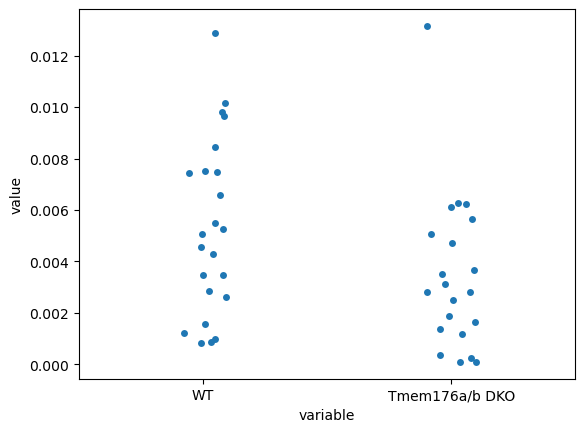

In [41]:
sns.stripplot(df.melt().dropna(), x='variable', y='value')

# Figure 6

In [42]:
df= pd.read_excel('41467_2025_65060_MOESM11_ESM.xlsx', sheet_name='Figure 4B (Coloc KIAA1324)', skiprows=1)


In [43]:
df=df.replace('0,179571429*',0.179571429)

C:\Users\Leo\AppData\Local\Temp\ipykernel_15216\2112854063.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df=df.replace('0,179571429*',0.179571429)


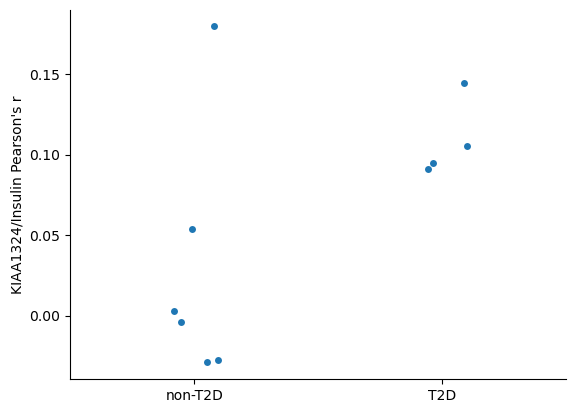

In [44]:
sns.stripplot(df.melt().dropna(), x='variable', y='value') 
sns.despine()
plt.xlabel('')
plt.ylabel('KIAA1324/Insulin Pearson\'s r')
plt.savefig('Suple/S2_Figure6A_data.svg')


In [45]:
# ------------------------------------------------------------
# Columns
# ------------------------------------------------------------
reference = "non-T2D"

comparison_cols = [
    "T2D"
]

In [46]:
results = []

for col in comparison_cols:

    nc = df[reference].dropna()
    other = df[col].dropna()

    # -------------------------
    # Normality
    # -------------------------
    nc_shapiro = shapiro(nc)
    other_shapiro = shapiro(other)

    # -------------------------
    # Equal variance
    # -------------------------
    lev = levene(
        nc,
        other,
        center="median"
    )

    # -------------------------
    # Student's t-test
    # Assumes equal variances
    # -------------------------
    student = ttest_ind(
        nc,
        other,
        equal_var=True
    )

    # -------------------------
    # Welch's t-test
    # Does NOT assume equal variances
    # -------------------------
    welch = ttest_ind(
        nc,
        other,
        equal_var=False
    )

    # -------------------------
    # Mann-Whitney U
    # -------------------------
    mw = mannwhitneyu(
        nc,
        other,
        alternative="two-sided"
    )

    results.append({
        "Gene": col,
        "NC_n": len(nc),
        "Other_n": len(other),

        "NC_Shapiro_p": nc_shapiro.pvalue,
        "Other_Shapiro_p": other_shapiro.pvalue,

        "Levene_p": lev.pvalue,

        "Student_t": student.statistic,
        "Student_p": student.pvalue,

        "Welch_t": welch.statistic,
        "Welch_p": welch.pvalue,

        "MW_U": mw.statistic,
        "MW_p": mw.pvalue,
    })


results_df = pd.DataFrame(results)


# ============================================================
# BY correction, separately for each family of tests
# ============================================================

results_df["Student_p_BY"] = multipletests(
    results_df["Student_p"],
    method="fdr_by"
)[1]

results_df["Welch_p_BY"] = multipletests(
    results_df["Welch_p"],
    method="fdr_by"
)[1]

results_df["MW_p_BY"] = multipletests(
    results_df["MW_p"],
    method="fdr_by"
)[1]


# ============================================================
# Significance
# ============================================================

results_df["Student_sig"] = results_df["Student_p_BY"] < 0.05
results_df["Welch_sig"] = results_df["Welch_p_BY"] < 0.05
results_df["MW_sig"] = results_df["MW_p_BY"] < 0.05


# ============================================================
# Nice rounding
# ============================================================

p_cols = [
    "NC_Shapiro_p",
    "Other_Shapiro_p",
    "Levene_p",

    "Student_p",
    "Student_p_BY",

    "Welch_p",
    "Welch_p_BY",

    "MW_p",
    "MW_p_BY"
]

results_df[p_cols] = results_df[p_cols].round(6)

results_df

,Gene,NC_n,Other_n,NC_Shapiro_p,Other_Shapiro_p,Levene_p,Student_t,Student_p,Welch_t,Welch_p,MW_U,MW_p,Student_p_BY,Welch_p_BY,MW_p_BY,Student_sig,Welch_sig,MW_sig
0,T2D,6,4,0.043392,0.149058,0.362543,-1.907722,0.092857,-2.294823,0.059507,4.0,0.114286,0.092857,0.059507,0.114286,False,False,False
